<a href="https://colab.research.google.com/github/mariiamyahiia/AI-fraud-detection/blob/Feature_Engineering_and_imbalance/notebooks/02_feature_engineering_and_imbalance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **1.IMPORT LIBRARIES**

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#To view all the columns
pd.set_option('display.max_columns', None)

# **2.LOAD FILES**

In [17]:
X_train = pd.read_parquet('/content/X_train.parquet')
X_test = pd.read_parquet('/content/X_test.parquet')
y_train = pd.read_parquet('/content/y_train.parquet').squeeze()
y_test = pd.read_parquet('/content/y_test.parquet').squeeze()

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (226980, 30)
X_test: (56746, 30)
y_train: (226980,)
y_test: (56746,)


# **3.CLASS IMBALANCE**

In [18]:
class_counts = y_train.value_counts().sort_index()
class_percent = y_train.value_counts(normalize=True).sort_index() * 100

class_summary = pd.DataFrame({
    'Count': class_counts,
    'Percentage': class_percent
})

class_summary.index = ['Normal (0)', 'Fraud (1)']

class_summary

,Count,Percentage
Normal (0),226602,99.833466
Fraud (1),378,0.166534


# **4.CLASS DISTRIBUTION**

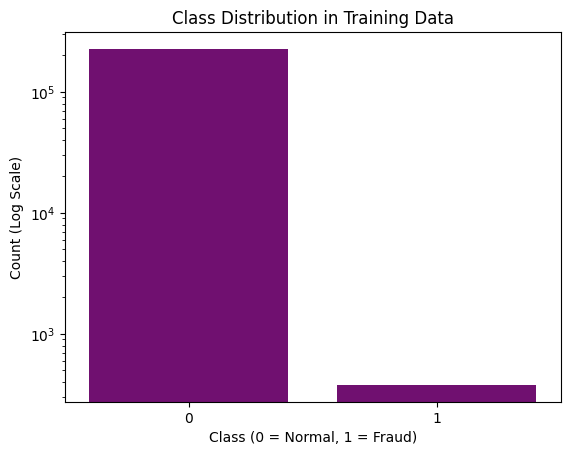

In [19]:
sns.countplot(x=y_train, color = "Purple")

plt.yscale('log')
plt.title('Class Distribution in Training Data')
plt.xlabel('Class (0 = Normal, 1 = Fraud)')
plt.ylabel('Count (Log Scale)')

plt.show()

# **5. FEATURE ANALYSIS**

In [20]:
train_analysis = X_train.copy()
train_analysis['Class'] = y_train.values

correlation = (
    train_analysis.corr()['Class']
    .drop('Class')
    .sort_values(key=abs, ascending=False)
)

correlation

,Class
V17,-0.320670
V14,-0.301644
V12,-0.254684
V10,-0.211641
V16,-0.190323
V3,-0.188869
V7,-0.180981
V11,0.152115
V4,0.129719
V18,-0.107100


# **6.MUTUAL INFORMATION**

In [21]:
from sklearn.feature_selection import mutual_info_classif

mi_scores = mutual_info_classif(
    X_train,
    y_train,
    random_state=42
)

mi_scores = pd.Series(
    mi_scores,
    index=X_train.columns
).sort_values(ascending=False)

mi_scores

,0
V17,0.008013
V14,0.007946
V10,0.007320
V12,0.007315
V11,0.006577
V16,0.005876
V3,0.004671
V4,0.004623
V9,0.004051
V18,0.003992


### Feature Analysis Conclusion

Correlation and Mutual Information were used to evaluate the relationship
between the input features and the fraud target.

Features such as V17, V14, V10, V12, and V11 showed relatively strong
relationships with the target.

However, low individual scores do not necessarily mean that a feature is
useless, since features may contribute through interactions with other
variables. Therefore, all 30 features were retained for the next stage.

# **7.CLASS WEIGHTS**

In [22]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train)

weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)

class_weights = dict(zip(classes, weights))

class_weights

{np.int64(0): np.float64(0.5008340614822464),
 np.int64(1): np.float64(300.23809523809524)}

# **8.SMOTE**

In [23]:
smote = SMOTE(
    sampling_strategy=0.1,
    random_state=42
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

Before SMOTE:
Class
0    226602
1       378
Name: count, dtype: int64

After SMOTE:
Class
0    226602
1     22660
Name: count, dtype: int64


# **9.BEFORE AND AFTER SMOTE VISUALIZATION**

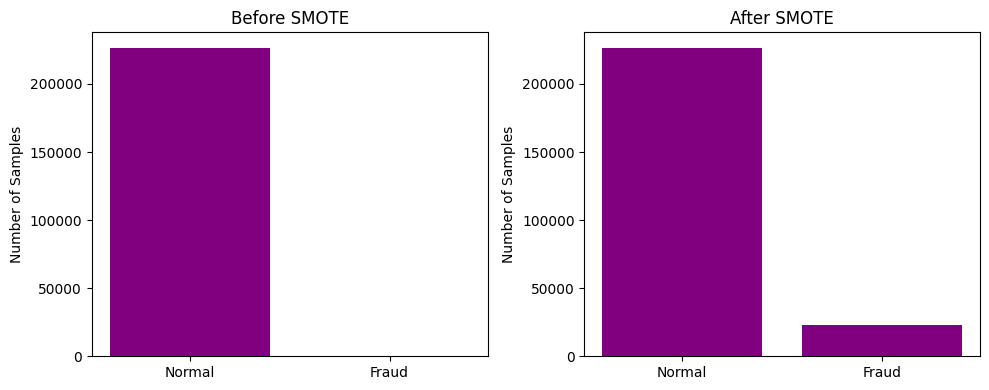

In [24]:
import matplotlib.pyplot as plt

before = y_train.value_counts().sort_index()
after = y_train_smote.value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(['Normal', 'Fraud'], before.values, color = "Purple")
axes[0].set_title('Before SMOTE')
axes[0].set_ylabel('Number of Samples')

axes[1].bar(['Normal', 'Fraud'], after.values, color = "Purple")
axes[1].set_title('After SMOTE')
axes[1].set_ylabel('Number of Samples')

plt.tight_layout()
plt.show()

# **10.SAVE SMOTE**

In [25]:
import os

os.makedirs('/content/member2_outputs', exist_ok=True)

X_train_smote.to_parquet(
    '/content/member2_outputs/X_train_smote.parquet',
    index=False
)

y_train_smote.to_frame(name='Class').to_parquet(
    '/content/member2_outputs/y_train_smote.parquet',
    index=False
)

print("SMOTE files saved successfully!")

SMOTE files saved successfully!


# **11.SAVE CLASS WEIGHTS**

In [26]:
import json

class_weights_clean = {
    int(k): float(v)
    for k, v in class_weights.items()
}

with open('/content/member2_outputs/class_weights.json', 'w') as f:
    json.dump(class_weights_clean, f, indent=4)

print(class_weights_clean)
print("Class weights saved successfully!")

{0: 0.5008340614822464, 1: 300.23809523809524}
Class weights saved successfully!


## Member 2 - Feature Engineering and Imbalanced Data Handling

### Feature Analysis
- Correlation analysis and Mutual Information were used to examine the relationship between the features and the target variable.
- V17, V14, V10, V12, and V11 were among the most informative features.
- All 30 features were retained because low individual scores do not necessarily mean that a feature is not useful when combined with other features.

### Class Imbalance
The training dataset was highly imbalanced:
- Normal transactions: 226,602 (99.83%)
- Fraud transactions: 378 (0.17%)

### Imbalance Handling
Two strategies were prepared:

1. **Class Weights**
   - Normal (0): 0.5008
   - Fraud (1): 300.2381

2. **SMOTE**
   - Applied only to the training data.
   - Normal samples remained 226,602.
   - Fraud samples increased from 378 to 22,660.
   - A sampling strategy of 0.1 was used to reduce the imbalance without forcing a 50/50 distribution.

### Outputs
- `X_train_smote.parquet`
- `y_train_smote.parquet`
- `class_weights.json`

The original test data was not modified or resampled.

# **12.ZIP FILE**

In [28]:
import shutil

shutil.make_archive(
    '/content/member2_outputs',
    'zip',
    '/content/member2_outputs'
)

print("ZIP created successfully!")

ZIP created successfully!
